## Modern Coexistence Theory (MCT): Application to auxotrophy model
In this workbook we demonstrate the mapping between the mechanistic cross-feeding model and MCT through the two-species gLV-based definition of niche overlap and fitness ratio. More generally, the techniques we demonstrate here can be applied to any mechanistic model through this method.

This is used to generate Figs. 4, 5 and S7

In [111]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [113]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [205]:
#2-species function test
Kms = np.array([[0.8,-1,1.8],[-1,1.4,0.7]]) #Proline auxotroph then tryptophan auxotroph
Ys = np.array([[5,0,1],[0,10,1]])
Cs = np.array([[0,0.025,-1],[0.05,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 0.4

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

DilRate = 0.03

Run through the different input concentrations of the two amino acids and map the resulting equilibrium communities to the niche overlap/fitness ratio axes. This code also generates countours on these axes representing combinations of input amino acid concentrations that have equal ratios but varying overall amount, and equal overall amount but varying ratios. 

C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:39: RuntimeWarning: invalid value encountered in sqrt
  rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:41: RuntimeWarning: invalid value encountered in sqrt
  fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:93: RuntimeWarning: invalid value encountered in sqrt
  rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:94: RuntimeWarning: invalid value encountered in sqrt
  fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:121: RuntimeWarning: invalid value encountered in sqrt
  rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\2852784600.py:122: Run

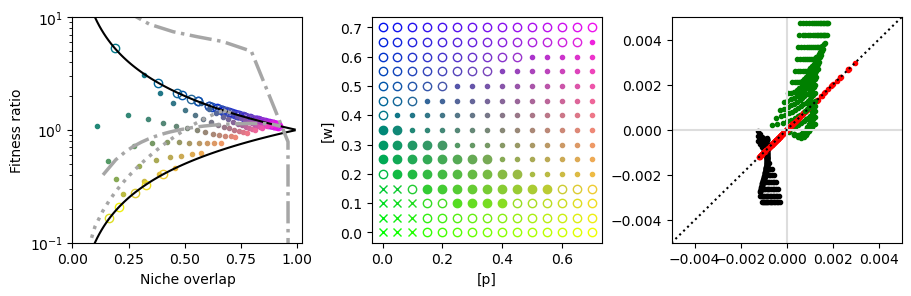

In [209]:
fig, axAr = plt.subplots(nrows = 1, ncols = 3, constrained_layout = True, figsize=(9,2.85))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

B0 = np.array([0.2,0.2])

noPts = 15

#Lattice of different concentrations
for i in range(noPts):
    for j in range(noPts):
        proConc = i*0.05
        tryConc = j*0.05

        rIn = np.array([proConc,tryConc,2.0])
        sysParams = {'rIn':rIn}
    
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
    
        chemSim.simEOmodel('Chemostat')
    
        chemSim.rStar = chemSim.resTimeseries[:,-1]
        A = chemSim.assembleIntMat(chemSim.rStar)
        mu = chemSim.assembleGRvec(chemSim.rStar)

        #These metrics are not valid if you have non-competitive interaction values. Flag systems with net + values
        if np.sum(np.sum(A<0)) < 4:
            NAflag = True
        else:
            NAflag = False
    
        coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
        
        rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
        #fitRat = np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        #fitRat = mu[0]/mu[1]

        colVec = np.array([i/(noPts),1-j/(noPts),j/(noPts)])
        if coexists == 1:
            if not(NAflag):
                ax1.plot(rho,fitRat,'o',color=colVec,fillstyle='none')
                
            ax2.plot(proConc,tryConc,'o',color=colVec,fillstyle='none')
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 2:
            if not(NAflag):
                ax1.plot(rho,fitRat,'.',color=colVec)
                
            ax2.plot(proConc,tryConc,'.',color=colVec)
            
            if NAflag:
                ax2.plot(proConc,tryConc,'o',color=colVec)
                
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 0:
            ax2.plot(proConc,tryConc,'x',color=colVec)

fitRatsIsoRat = np.zeros((noPts*10))
rhosIsoRat = np.zeros((noPts*10))

#Sweep through total concentrations at fixed (1:1) ratio of input amino acids
for i in range(noPts*10):
    proConc = i*0.005
    tryConc = i*0.005

    rIn = np.array([proConc,tryConc,2.0])
    sysParams = {'rIn':rIn}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
    
    rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

fitRatsIsoTotal = np.zeros((noPts*10))
rhosIsoTotal = np.zeros((noPts*10))

#Sweep through concentration ratios at fixed total concentration (0.5)
for i in range(noPts*10):
    proConc = i*0.0046667
    tryConc = 0.7-proConc

    rIn = np.array([proConc,tryConc,2.0])
    sysParams = {'rIn':rIn}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)
    
    rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoTotal[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

ax1.plot(np.arange(0.01,1,0.01),1/np.arange(0.01,1,0.01),'k')
ax1.plot(np.arange(0.01,1,0.01),np.arange(0.01,1,0.01),'k')
ax1.plot(rhosIsoRat,fitRatsIsoRat,'-.',color=(0.65,0.65,0.65),lw=2.5)
ax1.plot(rhosIsoTotal,fitRatsIsoTotal,':',color=(0.65,0.65,0.65),lw=2.5)
ax1.set_ylim([0.1,10])
ax1.set_xlim([-0,1.025])
ax1.set_yscale('log')
ax1.set_xlabel('Niche overlap')
ax1.set_ylabel('Fitness ratio')

#ax2.set_xscale('log')
#ax2.set_yscale('log')
ax2.set_xlabel('[p]')
ax2.set_ylabel('[w]')

ax3.plot([-0.02,0.02],[0,0],color = '#dddddd')
ax3.plot([0,0],[-0.02,0.02],color = '#dddddd')
ax3.plot([-0.02,0.02],[-0.02,0.02],'k:')
ax3.set_ylim([-0.005,0.005])
ax3.set_xlim([-0.005,0.005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT.pdf")

Repeat the same analysis, this time varying the amino acid production rates in place of the input concentrations.

<>:137: SyntaxWarning: invalid escape sequence '\D'
<>:138: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\D'
<>:138: SyntaxWarning: invalid escape sequence '\D'
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\1858449973.py:137: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_xlabel('$\Delta$ W leakage of p')
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\1858449973.py:138: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta$ P leakage of w')
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\1858449973.py:42: RuntimeWarning: invalid value encountered in scalar divide
  rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\1858449973.py:44: RuntimeWarning: invalid value encountered in scalar divide
  fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_47576\1858449973.py:44: RuntimeWarning: divide by ze

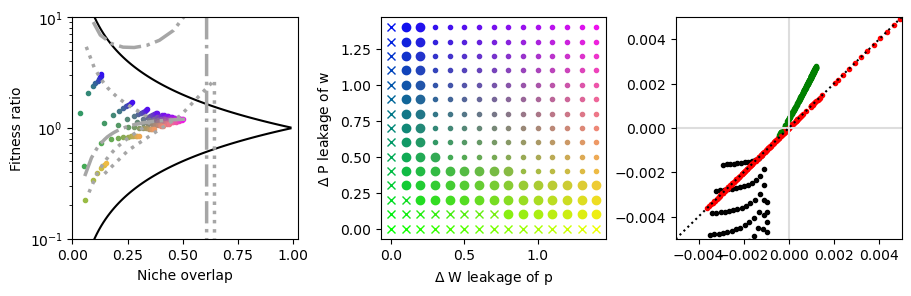

In [167]:
fig, axAr = plt.subplots(nrows = 1, ncols = 3, constrained_layout = True, figsize=(9,2.85))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

B0 = np.array([1,1])

noPts = 15

rIn = np.array([0,0,2.0])
sysParams = {'rIn':rIn}

#Logged version of the same
for i in range(noPts):
    for j in range(noPts):
        leakDelTry = i*0.1
        leakDelPro = j*0.1
        
        Cs = np.array([[0,leakDelPro,-1],[leakDelTry,0,-1]]) #Rate at which glucose is converted into relevant amino acids
        EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}
    
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
    
        chemSim.simEOmodel('Chemostat')
    
        chemSim.rStar = chemSim.resTimeseries[:,-1]
        A = chemSim.assembleIntMat(chemSim.rStar)
        mu = chemSim.assembleGRvec(chemSim.rStar)

        #These metrics are not valid if you have non-competitive interaction values. Flag systems with net + values
        if np.sum(np.sum(A<0)) < 4:
            NAflag = True
        else:
            NAflag = False
    
        coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
        
        rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
        #fitRat = np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))
        #fitRat = mu[0]/mu[1]

        colVec = np.array([i/(noPts),1-j/(noPts),j/(noPts)])
        if coexists == 1:
            if not(NAflag):
                ax1.plot(rho,fitRat,'o',color=colVec,fillstyle='none')
            
            ax2.plot(leakDelTry,leakDelPro,'o',color=colVec,fillstyle='none')
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 2:
            if not(NAflag):
                ax1.plot(rho,fitRat,'.',color=colVec)
                
            ax2.plot(leakDelTry,leakDelPro,'.',color=colVec)
            
            if NAflag:
                ax2.plot(leakDelTry,leakDelPro,'o',color=colVec)
            
            ax3.plot(A[0,0],A[1,1],'k.')
            ax3.plot(A[0,1],A[0,1],'r.')
            ax3.plot(mu[0],mu[1],'g.')
        elif coexists == 0:
            ax2.plot(leakDelTry,leakDelPro,'x',color=colVec)

fitRatsIsoRat = np.zeros((noPts*10))
rhosIsoRat = np.zeros((noPts*10))

for i in range(noPts*10):
    leakDelTry = i*0.01
    leakDelPro = i*0.01

    Cs = np.array([[0,leakDelPro,-1],[leakDelTry,0,-1]]) #Rate at which glucose is converted into relevant amino acids
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
    
    rhosIsoRat[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoRat[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

fitRatsIsoTotal = np.zeros((noPts*10))
rhosIsoTotal = np.zeros((noPts*10))

for i in range(noPts*10):
    leakDelTry = i*0.01
    leakDelPro = 1.5-leakDelTry

    Cs = np.array([[0,leakDelPro,-1],[leakDelTry,0,-1]]) #Rate at which glucose is converted into relevant amino acids
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    chemSim.rStar = chemSim.resTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.001)
    
    rhosIsoTotal[i] = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
    fitRatsIsoTotal[i] = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

ax1.plot(np.arange(0.01,1,0.01),1/np.arange(0.01,1,0.01),'k')
ax1.plot(np.arange(0.01,1,0.01),np.arange(0.01,1,0.01),'k')
ax1.plot(rhosIsoRat,fitRatsIsoRat,'-.',color=(0.65,0.65,0.65),lw=2.5)
ax1.plot(rhosIsoTotal,fitRatsIsoTotal,':',color=(0.65,0.65,0.65),lw=2.5)
ax1.set_ylim([0.1,10])
ax1.set_xlim([-0,1.025])
ax1.set_yscale('log')
ax1.set_xlabel('Niche overlap')
ax1.set_ylabel('Fitness ratio')

#ax2.set_xscale('log')
#ax2.set_yscale('log')
ax2.set_xlabel('$\Delta$ W leakage of p')
ax2.set_ylabel('$\Delta$ P leakage of w')

ax3.plot([-0.02,0.02],[0,0],color = '#dddddd')
ax3.plot([0,0],[-0.02,0.02],color = '#dddddd')
ax3.plot([-0.02,0.02],[-0.02,0.02],'k:')
ax3.set_ylim([-0.005,0.005])
ax3.set_xlim([-0.005,0.005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT2.pdf")

To understand how amino acid production rates and input concentrations drive variations on the MCT axes, we now adopt a sampling approach to investigate equilibrium properties of systems with random combinations of these parameters. We sample 100000 such randomised communities and determine where each lands on the fitness ratio/niche overlap axes. Statistics (including equilibrium nutrient concentrations, parameter values and effective gLV parameters) are then binned based on this mapping.

In [211]:
noReps = 100000
noBins = 15

B0 = np.array([0.1,0.1])

#Allogenic accels
m1Grid = [ [np.array([])]*noBins for i in range(noBins)]
m2Grid = [ [np.array([])]*noBins for i in range(noBins)]
#Autogenic accels
a11Grid = [ [np.array([])]*noBins for i in range(noBins)]
a22Grid = [ [np.array([])]*noBins for i in range(noBins)]
a12Grid = [ [np.array([])]*noBins for i in range(noBins)]
a21Grid = [ [np.array([])]*noBins for i in range(noBins)]
#SS-amino acid concs
wGrid = [ [np.array([])]*noBins for i in range(noBins)]
vGrid = [ [np.array([])]*noBins for i in range(noBins)]
cGrid = [ [np.array([])]*noBins for i in range(noBins)]
#Production rates
l1Grid = [ [np.array([])]*noBins for i in range(noBins)]
l2Grid = [ [np.array([])]*noBins for i in range(noBins)]
#Input rates
r1Grid = [ [np.array([])]*noBins for i in range(noBins)]
r2Grid = [ [np.array([])]*noBins for i in range(noBins)]

fluxRats = np.array([])
fitRats = np.array([])

for i in range(noReps):    
    leakDelPro = np.random.rand(1)*1.5 #Production of tryptophan by proline auxotroph
    leakDelTry = np.random.rand(1)*1.5 #Production of proline by tryptophan auxotroph
    proConc = np.random.rand(1)
    tryConc = np.random.rand(1)
        
    Cs = np.array([[0,leakDelPro[0],-1],[leakDelTry[0],0,-1]]) #Rate at which glucose is converted into relevant amino acids
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

    rIn = np.array([proConc[0],tryConc[0],2.0])
    sysParams = {'rIn':rIn}
    
    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,2000], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)
    
    chemSim.simEOmodel('Chemostat')
    chemSim.rStar = chemSim.resTimeseries[:,-1]
    chemSim.xStar = chemSim.specTimeseries[:,-1]
    A = chemSim.assembleIntMat(chemSim.rStar)
    mu = chemSim.assembleGRvec(chemSim.rStar)

    #These metrics are not valid if you have non-competitive interaction values. Flag systems with net + values
    if np.sum(np.sum(A<0)) < 4:
        NAflag = True
    else:
        NAflag = False

    coexists = sum(chemSim.specTimeseries[:,-1] > 0.0001)

    if coexists == 2 and not(NAflag):
        rho = np.sqrt((A[0,1] * A[1,0])/(A[0,0] * A[1,1]))
        fitRat = (mu[1]/mu[0])*np.sqrt((A[0,0] * A[0,1])/(A[1,1] * A[1,0]))

        if rho > 0 and rho < 1 and fitRat > 0.1 and fitRat < 10:
            #Define bins in which chemical concentrations will be collated
            transFitRat = (np.log10(fitRat)+1)/2 #Ensures it varies between 0 and 1
            rhoBin = int(np.floor(rho*noBins))
            fitRatBin = int(np.floor(transFitRat*noBins))

            m1Grid[fitRatBin][rhoBin] = np.append(m1Grid[rhoBin][fitRatBin],mu[0])
            m2Grid[fitRatBin][rhoBin] = np.append(m2Grid[rhoBin][fitRatBin],mu[1])
            a11Grid[fitRatBin][rhoBin] = np.append(a11Grid[rhoBin][fitRatBin],A[0,0])
            a22Grid[fitRatBin][rhoBin] = np.append(a22Grid[rhoBin][fitRatBin],A[1,1])
            a12Grid[fitRatBin][rhoBin] = np.append(a12Grid[rhoBin][fitRatBin],A[0,1])
            a21Grid[fitRatBin][rhoBin] = np.append(a21Grid[rhoBin][fitRatBin],A[1,0])
            wGrid[fitRatBin][rhoBin] = np.append(wGrid[rhoBin][fitRatBin],chemSim.rStar[0])
            vGrid[fitRatBin][rhoBin] = np.append(vGrid[rhoBin][fitRatBin],chemSim.rStar[1])
            cGrid[fitRatBin][rhoBin] = np.append(cGrid[rhoBin][fitRatBin],chemSim.rStar[2])
            l1Grid[fitRatBin][rhoBin] = np.append(l1Grid[rhoBin][fitRatBin],leakDelTry[0])
            l2Grid[fitRatBin][rhoBin] = np.append(l2Grid[rhoBin][fitRatBin],leakDelPro[0])
            r1Grid[fitRatBin][rhoBin] = np.append(r1Grid[rhoBin][fitRatBin],proConc[0])
            r2Grid[fitRatBin][rhoBin] = np.append(r2Grid[rhoBin][fitRatBin],tryConc[0])

            #fitRats = np.append(fitRats,fitRat)
            #gM1 = chemSim.rStar[2]/(chemSim.rStar[2] + Kms[0,2])
            #gM2 = chemSim.rStar[2]/(chemSim.rStar[2] + Kms[1,2])
            #fluxGuess = (DilRate*(proConc-chemSim.rStar[0]) + chemSim.xStar[1]*gM2*leakDelTry*Vmax)/(DilRate*(tryConc-chemSim.rStar[1]) + chemSim.xStar[0]*gM1*leakDelPro*Vmax)
            #fluxGuess = (proConc-chemSim.rStar[0])/(tryConc-chemSim.rStar[1])
            #fluxGuess = chemSim.xStar[1]*gM2*leakDelTry/chemSim.xStar[0]*gM1*leakDelPro
            #fluxRats = np.append(fluxRats,fluxGuess)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [213]:
m1Means = np.zeros((noBins,noBins))
m2Means = np.zeros((noBins,noBins))

a11Means = np.zeros((noBins,noBins))
a22Means = np.zeros((noBins,noBins))
a12Means = np.zeros((noBins,noBins))
a21Means = np.zeros((noBins,noBins))

wMeans = np.zeros((noBins,noBins))
vMeans = np.zeros((noBins,noBins))
cMeans = np.zeros((noBins,noBins))

l1Means = np.zeros((noBins,noBins))
l2Means = np.zeros((noBins,noBins))

r1Means = np.zeros((noBins,noBins))
r2Means = np.zeros((noBins,noBins))

for i in range(noBins):
    for j in range(noBins):
        m1Means[i][j] = np.mean(m1Grid[i][j])
        m2Means[i][j] = np.mean(m2Grid[i][j])
        
        a11Means[i][j] = np.mean(a11Grid[i][j])
        a22Means[i][j] = np.mean(a22Grid[i][j])
        a12Means[i][j] = np.mean(a12Grid[i][j])
        a21Means[i][j] = np.mean(a21Grid[i][j])
        
        wMeans[i][j] = np.mean(wGrid[i][j])
        vMeans[i][j] = np.mean(vGrid[i][j])
        cMeans[i][j] = np.mean(cGrid[i][j])

        l1Means[i][j] = np.mean(l1Grid[i][j])
        l2Means[i][j] = np.mean(l2Grid[i][j])
        r1Means[i][j] = np.mean(r1Grid[i][j])
        r2Means[i][j] = np.mean(r2Grid[i][j])

C:\Users\bi1ojm\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\bi1ojm\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


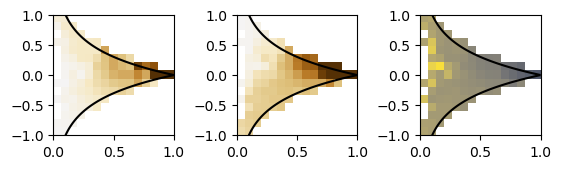

In [229]:
fig, axAr = plt.subplots(nrows = 1, ncols = 3, constrained_layout = True, figsize=(5.5,1.6))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

aLimUp = 0.004
aLimLow = -0.004
cLim = 0.6

#Auto for W auxotroph on P auxotroph
axAr[0].imshow(a12Means,cmap='BrBG',vmin = aLimLow, vmax = aLimUp,extent=[0,1,-1,1], origin='lower')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[0].set_aspect(0.5)

#Auto for P auxotroph on W auxotroph
axAr[1].imshow(a21Means,cmap='BrBG',vmin = aLimLow, vmax = aLimUp,extent=[0,1,-1,1], origin='lower')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[1].set_aspect(0.5)

#Carbon concentrations
axAr[2].imshow(cMeans,cmap='cividis',vmin = 0, vmax = cLim,extent=[0,1,-1,1], origin='lower')
axAr[2].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[2].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[2].set_aspect(0.5)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT_HeatmapsInterPlusC.pdf")

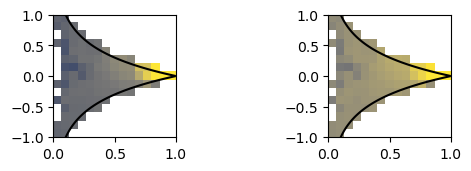

In [231]:
#Plot amino acid concs
fig, axAr = plt.subplots(nrows = 1, ncols = 2, constrained_layout = True, figsize=(5.5,1.6))
ax1=axAr[0]
ax2=axAr[1]

#W concentrations
axAr[0].imshow(wMeans,cmap='cividis',vmin = 0, vmax = 1.4,extent=[0,1,-1,1], origin='lower')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[0].set_aspect(0.5)

#P concentrations
axAr[1].imshow(vMeans,cmap='cividis',vmin = 0, vmax = 0.6,extent=[0,1,-1,1], origin='lower')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[1].set_aspect(0.5)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT_HeatmapsVandW.pdf")

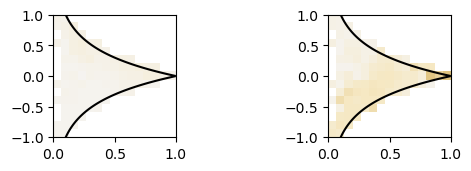

In [225]:
#Plot intraspecific interacts
fig, axAr = plt.subplots(nrows = 1, ncols = 2, constrained_layout = True, figsize=(5.5,1.6))
ax1=axAr[0]
ax2=axAr[1]

aLimUp = 0.04
aLimLow = -0.04

#Auto for P auxo on P auxo
axAr[0].imshow(a11Means,cmap='BrBG',vmin = aLimLow, vmax = aLimUp,extent=[0,1,-1,1], origin='lower')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[0].set_aspect(0.5)

#Auto for W auxo on W auxo
axAr[1].imshow(a22Means,cmap='BrBG',vmin = aLimLow, vmax = aLimUp,extent=[0,1,-1,1], origin='lower')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[1].set_aspect(0.5)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT_HeatmapsIntra.pdf")

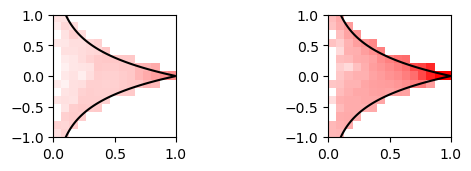

In [221]:
#Plot allogenic accelerations
fig, axAr = plt.subplots(nrows = 1, ncols = 2, constrained_layout = True, figsize=(5.5,1.6))
ax1=axAr[0]
ax2=axAr[1]

mLimUp = 0.006
mLimLow = -0.006

#Allo for P auxotroph
axAr[0].imshow(m1Means,cmap='bwr',vmin = mLimLow, vmax = mLimUp,extent=[0,1,-1,1], origin='lower')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[0].set_aspect(0.5)

#Allo for W auxotroph
axAr[1].imshow(m2Means,cmap='bwr',vmin = mLimLow, vmax = mLimUp,extent=[0,1,-1,1], origin='lower')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[1].set_aspect(0.5)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT_HeatmapsAllogenic.pdf")

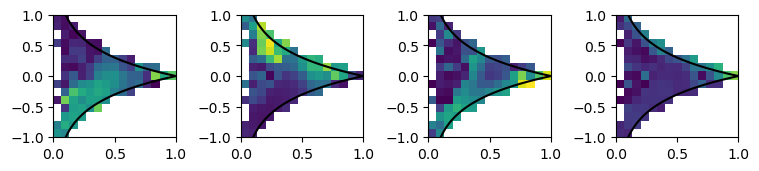

In [223]:
fig, axAr = plt.subplots(nrows = 1, ncols = 4, constrained_layout = True, figsize=(7.5,1.6))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]
ax4=axAr[3]

cLim = 1.5

#Leakage of p by w auxotroph
axAr[0].imshow(l1Means,vmin = 0, vmax = cLim,extent=[0,1,-1,1], origin='lower')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[0].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[0].set_aspect(0.5)

#Leakage of w by p auxotroph
axAr[1].imshow(l2Means,vmin = 0, vmax = cLim,extent=[0,1,-1,1], origin='lower')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[1].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[1].set_aspect(0.5)

cLim = 1

#Input of p
axAr[2].imshow(r1Means,vmin = 0, vmax = cLim,extent=[0,1,-1,1], origin='lower')
axAr[2].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[2].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[2].set_aspect(0.5)

#Input of w
axAr[3].imshow(r2Means,vmin = 0, vmax = cLim,extent=[0,1,-1,1], origin='lower')
axAr[3].plot(np.arange(0.1,1,0.01),np.log10(1/np.arange(0.1,1,0.01)),'k')
axAr[3].plot(np.arange(0.1,1,0.01),np.log10(np.arange(0.1,1,0.01)),'k')
axAr[3].set_aspect(0.5)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophMCT_HeatmapsParameters.pdf")